In [5]:
import pandas as pd
# CSVファイルを読み込む（ファイル名はダウンロードしたものに合わせて書き換えてね！）
# 例: 'steam_games.csv' 
df = pd.read_csv('steam_games.csv')

In [6]:
# 読み込みが成功したか、先頭の5行だけを表示して確認する
df.head()
# データの形状（行数、列数）を確認する
print("データの形状 (行数, 列数):", df.shape)
# 列の情報、データ型、欠損値（空っぽのセル）の数を確認する
df.info()
# 数値データの要約統計量（平均、最小、最大など）を確認する
df.describe()

import numpy as np
# 「Required ageが19以上」のデータのRequired ageを、データなし（NaN）に書き換える
df.loc[df['Required age'] >= 19, 'Required age'] = np.nan
# 小数点以下を切り捨てて、整数（18.99 → 18）にする
# （データなしのNaNが入っているため、float型のまま整数化します）
df['Required age'] = df['Required age'].apply(lambda x: int(x) if pd.notnull(x) else x)
# もう一度確認する
df['Required age'].describe()

# 「Priceが0」なら True、0より大きければ False になる『Is_Free』という新しい列を作る
df['Is_Free'] = df['Price'] == 0
# 新しい列がちゃんと作れたか、先頭の5行を表示して確認する
# （一番右側に 'Is_Free' という列が追加されているはず！）
df[['Name', 'Price', 'Is_Free']].head()
# 無料（True）と有料（False）のゲーム数をそれぞれカウントする
df['Is_Free'].value_counts()

# 各列に「空っぽのセル（欠損値）」が何個あるか、合計を数える
df.isnull().sum()

データの形状 (行数, 列数): (122611, 39)
<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  object 
 1   Name                        122611 non-null  object 
 2   Release date                122611 non-null  object 
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-n

AppID                              1
Name                               0
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                    3920
Price                              0
DiscountDLC count                  0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
Recommendations                    0
N

In [7]:
# 1. まずはGenres列の空っぽのセル(NaN)を 'Unknown' という文字で埋める
df['Genres'] = df['Genres'].fillna('Unknown')

# 2. ジャンルが「Action;Indie;RPG」のようにセミコロンで繋がっているので、バラバラにしてリスト化する
# (ついでに前後の余計なスペースも消しちゃうジェダイの技)
df['Genre_List'] = df['Genres'].apply(lambda x: [g.strip() for g in str(x).split(';') if g.strip()])

# 3. ちゃんとバラバラにできたか、上から5行だけ確認する
df[['Name', 'Genres', 'Genre_List']].head()

,Name,Genres,Genre_List
2539430,"Aug 1, 2023",Unknown,[Unknown]
496350,"Jul 29, 2016",Adventure,[Adventure]
1034400,"May 6, 2019",Casual,[Casual]
3292190,"Oct 31, 2024","Casual,Indie,Simulation","[Casual,Indie,Simulation]"
3631080,"Apr 24, 2025","Action,Early Access","[Action,Early Access]"


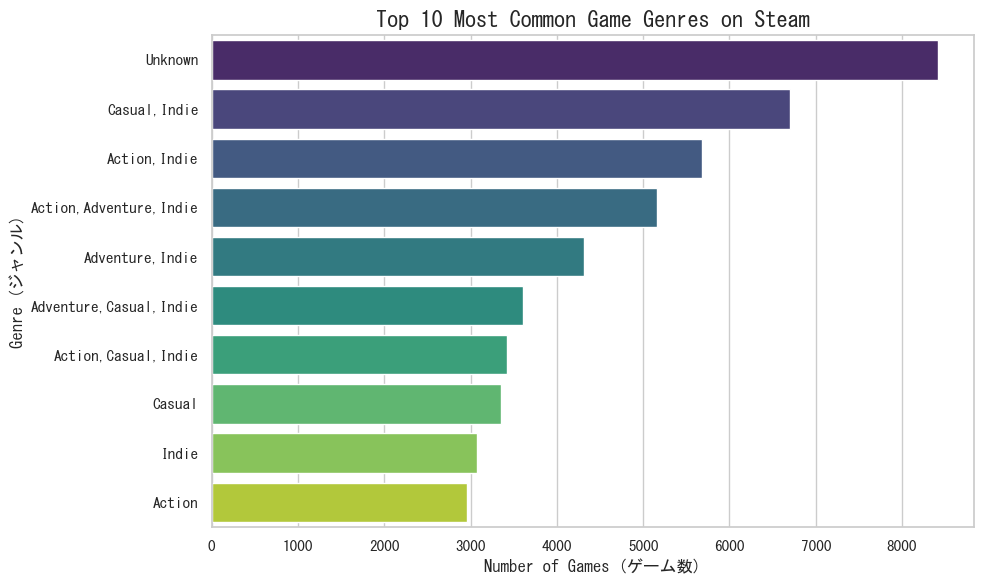

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 【修正ポイント1】日本語の文字化けを防ぐフォント設定（Windows用）
plt.rcParams['font.family'] = 'MS Gothic'

# 1. バラバラにしたジャンルをすべて1つの巨大なリストに集約する
all_genres = []
for genres in df['Genre_List']:
    all_genres.extend(genres)

# 2. ジャンルごとの出現回数を数えて、上位10件を引っ張ってくる
genre_counts = pd.Series(all_genres).value_counts().head(10)

# 3. グラフのサイズと見た目のテーマを設定する
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", font='MS Gothic') # テーマ側にもフォントを指定

# 4. 【修正ポイント2】Seabornの警告が出ないように hue と legend を追加
sns.barplot(
    x=genre_counts.values, 
    y=genre_counts.index, 
    hue=genre_counts.index, # hueを追加して警告を消す
    palette="viridis", 
    legend=False            # 凡例は不要なので非表示に
)

# 5. グラフのタイトルやラベルをつける
plt.title('Top 10 Most Common Game Genres on Steam', fontsize=16, fontweight='bold')
plt.xlabel('Number of Games (ゲーム数)', fontsize=12)
plt.ylabel('Genre (ジャンル)', fontsize=12)

# 6. 画面に表示する
plt.tight_layout()
plt.show()


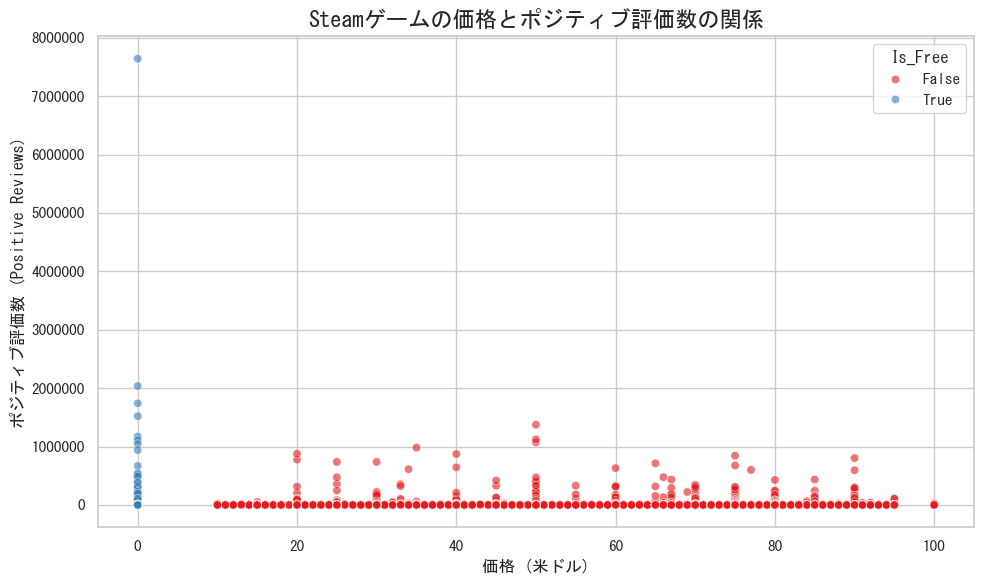

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# グラフのサイズとフォントを設定
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'MS Gothic'

# 100ドル以下のゲームに絞って、価格とポジティブ評価数の関係をプロット
# 無料（True）と有料（False）で色を分ける（hue="Is_Free"）
sns.scatterplot(
    data=df[df['Price'] <= 100], 
    x='Price', 
    y='Positive', 
    hue='Is_Free', 
    palette='Set1', 
    alpha=0.6
)

# グラフのタイトルやラベルを設定
plt.title('Steamゲームの価格とポジティブ評価数の関係', fontsize=16, fontweight='bold')
plt.xlabel('価格 (米ドル)', fontsize=12)
plt.ylabel('ポジティブ評価数 (Positive Reviews)', fontsize=12)

# Y軸の桁が大きくなるので見やすくする
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

# グラフを「steam_scatter_plot.png」という名前で高画質（dpi=300）保存する
plt.savefig('steam_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()